In [1]:
import pickle

with open('../backend/app/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_final = data['X_train_final']
X_test_final = data['X_test_final']
y_train = data['y_train']
y_test = data['y_test']

print(X_train_final.shape)
print(X_test_final.shape)
print(y_train.value_counts())

(14304, 5031)
(3576, 5031)
fraudulent
0    13611
1      693
Name: count, dtype: int64


In [2]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_lr.fit(X_train_final, y_train)

print('Model trained!')

Model trained!


In [5]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

y_pred = model_lr.predict(X_test_final)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      3403
           1       0.54      0.93      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.95      0.83      3576
weighted avg       0.97      0.96      0.96      3576

[[3266  137]
 [  12  161]]


In [6]:
accuracy_score(y_test,y_pred)

0.9583333333333334

In [7]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
model_rf.fit(X_train_final, y_train)

y_pred_rf = model_rf.predict(X_test_final)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.53      0.69       173

    accuracy                           0.98      3576
   macro avg       0.98      0.77      0.84      3576
weighted avg       0.98      0.98      0.97      3576



In [8]:
accuracy_score(y_test,y_pred_rf)

0.977069351230425

In [9]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC(class_weight='balanced', max_iter=2000)
model_svm.fit(X_train_final, y_train)

y_pred_svm = model_svm.predict(X_test_final)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.78      0.90      0.84       173

    accuracy                           0.98      3576
   macro avg       0.89      0.94      0.91      3576
weighted avg       0.98      0.98      0.98      3576



In [10]:
accuracy_score(y_test,y_pred_svm)

0.9829418344519015

In [11]:
import pickle

with open('../backend/app/model.pkl', 'wb') as f:
    pickle.dump(model_svm, f)

print('Best model saved!')

Best model saved!


In [13]:
import pickle

with open('../backend/app/tfidf.pkl', 'rb') as f:
    tfidf = pickle.load(f)

print('TF-IDF loaded!')

TF-IDF loaded!


In [14]:
# Get TF-IDF feature names (the actual words)
tfidf_features = tfidf.get_feature_names_out()

print(len(tfidf_features))
print(tfidf_features[:20])

5000
['00' '000' '0in' '10' '10 years' '100' '11' '12' '12 month' '12 months'
 '15' '1500' '1500 job' '1500 usd' '16' '16 18' '18' '18 year' '20' '200']


In [15]:
import numpy as np
svm_coefficients = model_svm.coef_[0][:5000]

print(svm_coefficients.shape)

(5000,)


In [16]:
import pandas as pd

feature_importance = pd.DataFrame({
    'word': tfidf_features,
    'weight': svm_coefficients
})


top_fake_words = feature_importance.sort_values('weight', ascending=False).head(20)
print(top_fake_words)

              word    weight
2452          link  2.638775
494       aptitude  2.377540
3778       signing  2.191534
578     associates  2.072316
2667         money  2.033284
183       american  1.868299
3044        out of  1.861691
2893          ohio  1.784889
1992           his  1.773847
3989      supplier  1.747255
1979   high school  1.730216
2891      offshore  1.654588
76      accountant  1.643413
2432    leveraging  1.641076
4983   your career  1.626072
1492       ensures  1.531099
2726     nbsp nbsp  1.526851
726         bottom  1.504105
295   and exciting  1.499238
692          below  1.498566


In [17]:

top_real_words = feature_importance.sort_values('weight', ascending=True).head(20)
print(top_real_words)

              word    weight
41              50 -1.907571
977      companies -1.652841
188             an -1.604935
2310            it -1.598201
2076        in all -1.584358
1475       english -1.505937
1571   exceptional -1.450613
1189        dealer -1.352653
1918      hardware -1.322378
1266       details -1.321969
3004           our -1.292559
2197  installation -1.278048
4939          year -1.274851
54           about -1.255446
1145        custom -1.231429
1806           fun -1.218587
1010    components -1.206455
3169           php -1.201292
1911      handling -1.198645
4046          team -1.191869


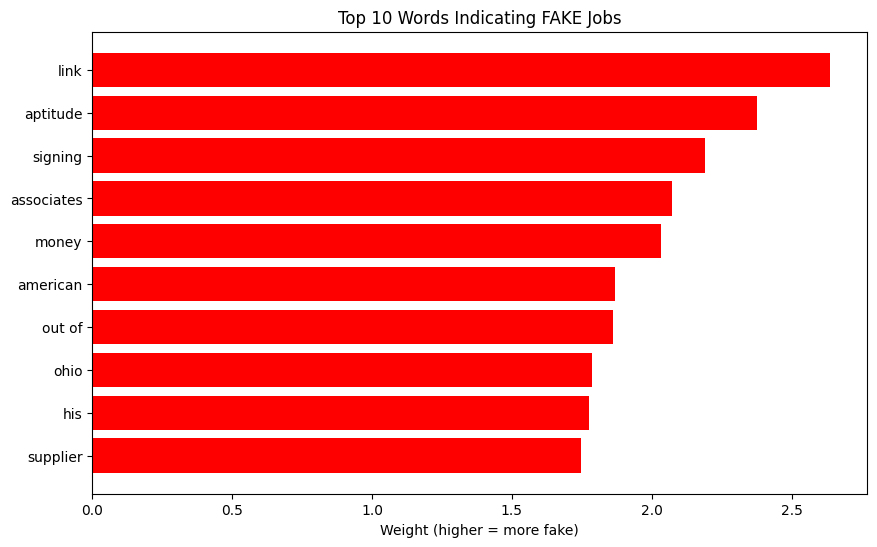

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_fake_words['word'][:10], top_fake_words['weight'][:10], color='red')
plt.xlabel('Weight (higher = more fake)')
plt.title('Top 10 Words Indicating FAKE Jobs')
plt.gca().invert_yaxis()
plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid_search = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

print('Best C:', grid_search.best_params_)
print('Best F1 Score:', grid_search.best_score_)

Best C: {'C': 10.0}
Best F1 Score: 0.7998567019400352


In [20]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_final)
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.84      0.84      0.84       173

    accuracy                           0.98      3576
   macro avg       0.92      0.92      0.92      3576
weighted avg       0.98      0.98      0.98      3576

